In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec

import warnings
warnings.filterwarnings("ignore")

In [17]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\VyshnavSudheesan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\VyshnavSudheesan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\VyshnavSudheesan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\VyshnavSudheesan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\VyshnavSudheesan\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
df = pd.read_csv("IHMStefanini_industrial_safety_and_health_database_with_accidents_description.csv")
df.head()

,Unnamed: 0,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description
0,0,2016-01-01 00:00:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...
1,1,2016-01-02 00:00:00,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...
2,2,2016-01-06 00:00:00,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...
3,3,2016-01-08 00:00:00,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...
4,4,2016-01-10 00:00:00,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...


In [5]:
print("Shape :", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nDataset Info:\n")
df.info()

Shape : (425, 11)

Columns:

Index(['Unnamed: 0', 'Data', 'Countries', 'Local', 'Industry Sector',
       'Accident Level', 'Potential Accident Level', 'Genre',
       'Employee or Third Party', 'Critical Risk', 'Description'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                425 non-null    int64 
 1   Data                      425 non-null    object
 2   Countries                 425 non-null    object
 3   Local                     425 non-null    object
 4   Industry Sector           425 non-null    object
 5   Accident Level            425 non-null    object
 6   Potential Accident Level  425 non-null    object
 7   Genre                     425 non-null    object
 8   Employee or Third Party   425 non-null    object
 9   Critical Risk             425 

In [6]:
df.isnull().sum()

Unnamed: 0                  0
Data                        0
Countries                   0
Local                       0
Industry Sector             0
Accident Level              0
Potential Accident Level    0
Genre                       0
Employee or Third Party     0
Critical Risk               0
Description                 0
dtype: int64

In [7]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [8]:
text_df = df[['Description']].copy()

text_df.head()

,Description
0,While removing the drill rod of the Jumbo 08 f...
1,During the activation of a sodium sulphide pum...
2,In the sub-station MILPO located at level +170...
3,Being 9:45 am. approximately in the Nv. 1880 C...
4,Approximately at 11:45 a.m. in circumstances t...


In [9]:
for i in range(5):
    print(f"\nDescription {i+1}")
    print(text_df['Description'][i])


Description 1
While removing the drill rod of the Jumbo 08 for maintenance, the supervisor proceeds to loosen the support of the intermediate centralizer to facilitate the removal, seeing this the mechanic supports one end on the drill of the equipment to pull with both hands the bar and accelerate the removal from this, at this moment the bar slides from its point of support and tightens the fingers of the mechanic between the drilling bar and the beam of the jumbo.

Description 2
During the activation of a sodium sulphide pump, the piping was uncoupled and the sulfide solution was designed in the area to reach the maid. Immediately she made use of the emergency shower and was directed to the ambulatory doctor and later to the hospital. Note: of sulphide solution = 48 grams / liter.

Description 3
In the sub-station MILPO located at level +170 when the collaborator was doing the excavation work with a pick (hand tool), hitting a rock with the flat part of the beak, it bounces off hit

In [10]:
text_df['Length'] = text_df['Description'].apply(len)

text_df['Length'].describe()

count     425.000000
mean      368.280000
std       178.944426
min        94.000000
25%       227.000000
50%       335.000000
75%       457.000000
max      1029.000000
Name: Length, dtype: float64

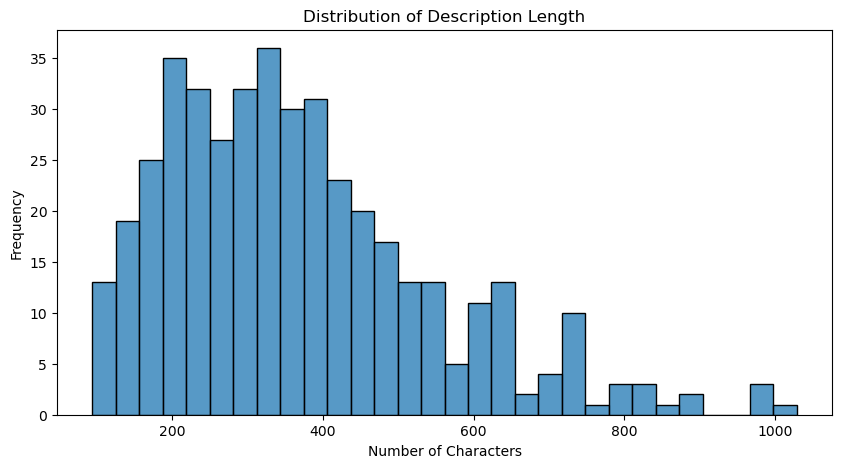

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(text_df['Length'], bins=30)

plt.title("Distribution of Description Length")

plt.xlabel("Number of Characters")

plt.ylabel("Frequency")

plt.show()

In [12]:
text_df['clean_text'] = text_df['Description'].str.lower()

text_df[['Description','clean_text']].head()

,Description,clean_text
0,While removing the drill rod of the Jumbo 08 f...,while removing the drill rod of the jumbo 08 f...
1,During the activation of a sodium sulphide pum...,during the activation of a sodium sulphide pum...
2,In the sub-station MILPO located at level +170...,in the sub-station milpo located at level +170...
3,Being 9:45 am. approximately in the Nv. 1880 C...,being 9:45 am. approximately in the nv. 1880 c...
4,Approximately at 11:45 a.m. in circumstances t...,approximately at 11:45 a.m. in circumstances t...


In [13]:
text_df['clean_text'] = text_df['clean_text'].str.replace(r'[^\w\s]', '', regex=True)

text_df[['Description','clean_text']].head()

,Description,clean_text
0,While removing the drill rod of the Jumbo 08 f...,while removing the drill rod of the jumbo 08 f...
1,During the activation of a sodium sulphide pum...,during the activation of a sodium sulphide pum...
2,In the sub-station MILPO located at level +170...,in the substation milpo located at level 170 w...
3,Being 9:45 am. approximately in the Nv. 1880 C...,being 945 am approximately in the nv 1880 cx69...
4,Approximately at 11:45 a.m. in circumstances t...,approximately at 1145 am in circumstances that...


In [14]:
text_df['clean_text'] = text_df['clean_text'].str.replace(r'\d+', '', regex=True)

text_df[['Description','clean_text']].head()

,Description,clean_text
0,While removing the drill rod of the Jumbo 08 f...,while removing the drill rod of the jumbo for...
1,During the activation of a sodium sulphide pum...,during the activation of a sodium sulphide pum...
2,In the sub-station MILPO located at level +170...,in the substation milpo located at level when...
3,Being 9:45 am. approximately in the Nv. 1880 C...,being am approximately in the nv cx ob the p...
4,Approximately at 11:45 a.m. in circumstances t...,approximately at am in circumstances that the...


In [15]:
text_df['clean_text'] = text_df['clean_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

text_df[['Description','clean_text']].head()

,Description,clean_text
0,While removing the drill rod of the Jumbo 08 f...,while removing the drill rod of the jumbo for ...
1,During the activation of a sodium sulphide pum...,during the activation of a sodium sulphide pum...
2,In the sub-station MILPO located at level +170...,in the substation milpo located at level when ...
3,Being 9:45 am. approximately in the Nv. 1880 C...,being am approximately in the nv cx ob the per...
4,Approximately at 11:45 a.m. in circumstances t...,approximately at am in circumstances that the ...


In [18]:
text_df['tokens'] = text_df['clean_text'].apply(word_tokenize)

text_df[['clean_text','tokens']].head()

,clean_text,tokens
0,while removing the drill rod of the jumbo for ...,"[while, removing, the, drill, rod, of, the, ju..."
1,during the activation of a sodium sulphide pum...,"[during, the, activation, of, a, sodium, sulph..."
2,in the substation milpo located at level when ...,"[in, the, substation, milpo, located, at, leve..."
3,being am approximately in the nv cx ob the per...,"[being, am, approximately, in, the, nv, cx, ob..."
4,approximately at am in circumstances that the ...,"[approximately, at, am, in, circumstances, tha..."


In [19]:
stop_words = set(stopwords.words('english'))

text_df['tokens_no_stopwords'] = text_df['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

text_df[['tokens','tokens_no_stopwords']].head()

,tokens,tokens_no_stopwords
0,"[while, removing, the, drill, rod, of, the, ju...","[removing, drill, rod, jumbo, maintenance, sup..."
1,"[during, the, activation, of, a, sodium, sulph...","[activation, sodium, sulphide, pump, piping, u..."
2,"[in, the, substation, milpo, located, at, leve...","[substation, milpo, located, level, collaborat..."
3,"[being, am, approximately, in, the, nv, cx, ob...","[approximately, nv, cx, ob, personnel, begins,..."
4,"[approximately, at, am, in, circumstances, tha...","[approximately, circumstances, mechanics, anth..."


In [20]:
stemmer = PorterStemmer()

text_df['stemmed'] = text_df['tokens_no_stopwords'].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

text_df[['tokens_no_stopwords','stemmed']].head()

,tokens_no_stopwords,stemmed
0,"[removing, drill, rod, jumbo, maintenance, sup...","[remov, drill, rod, jumbo, mainten, supervisor..."
1,"[activation, sodium, sulphide, pump, piping, u...","[activ, sodium, sulphid, pump, pipe, uncoupl, ..."
2,"[substation, milpo, located, level, collaborat...","[substat, milpo, locat, level, collabor, excav..."
3,"[approximately, nv, cx, ob, personnel, begins,...","[approxim, nv, cx, ob, personnel, begin, task,..."
4,"[approximately, circumstances, mechanics, anth...","[approxim, circumst, mechan, anthoni, group, l..."


In [21]:
lemmatizer = WordNetLemmatizer()

text_df['lemmatized'] = text_df['tokens_no_stopwords'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

text_df[['tokens_no_stopwords','lemmatized']].head()

,tokens_no_stopwords,lemmatized
0,"[removing, drill, rod, jumbo, maintenance, sup...","[removing, drill, rod, jumbo, maintenance, sup..."
1,"[activation, sodium, sulphide, pump, piping, u...","[activation, sodium, sulphide, pump, piping, u..."
2,"[substation, milpo, located, level, collaborat...","[substation, milpo, located, level, collaborat..."
3,"[approximately, nv, cx, ob, personnel, begins,...","[approximately, nv, cx, ob, personnel, begin, ..."
4,"[approximately, circumstances, mechanics, anth...","[approximately, circumstance, mechanic, anthon..."


In [22]:
text_df['processed_text'] = text_df['lemmatized'].apply(lambda words: ' '.join(words))

text_df[['Description', 'processed_text']].head()

,Description,processed_text
0,While removing the drill rod of the Jumbo 08 f...,removing drill rod jumbo maintenance superviso...
1,During the activation of a sodium sulphide pum...,activation sodium sulphide pump piping uncoupl...
2,In the sub-station MILPO located at level +170...,substation milpo located level collaborator ex...
3,Being 9:45 am. approximately in the Nv. 1880 C...,approximately nv cx ob personnel begin task un...
4,Approximately at 11:45 a.m. in circumstances t...,approximately circumstance mechanic anthony gr...


In [23]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer()

bow_matrix = bow.fit_transform(text_df['processed_text'])

print("Shape of Bag of Words Matrix:", bow_matrix.shape)

Shape of Bag of Words Matrix: (425, 2802)


In [24]:
print(list(bow.vocabulary_.keys())[:50])

['removing', 'drill', 'rod', 'jumbo', 'maintenance', 'supervisor', 'proceeds', 'loosen', 'support', 'intermediate', 'centralizer', 'facilitate', 'removal', 'seeing', 'mechanic', 'one', 'end', 'equipment', 'pull', 'hand', 'bar', 'accelerate', 'moment', 'slide', 'point', 'tightens', 'finger', 'drilling', 'beam', 'activation', 'sodium', 'sulphide', 'pump', 'piping', 'uncoupled', 'sulfide', 'solution', 'designed', 'area', 'reach', 'maid', 'immediately', 'made', 'use', 'emergency', 'shower', 'directed', 'ambulatory', 'doctor', 'later']


In [25]:
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow.get_feature_names_out()
)

bow_df.head()

,abb,abdomen,able,abratech,abrupt,abruptly,absorbent,absorbing,abutment,acc,...,yield,yolk,young,zaf,zamac,zero,zinc,zinco,zn,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(text_df['processed_text'])

print("Shape of TF-IDF Matrix:", tfidf_matrix.shape)

Shape of TF-IDF Matrix: (425, 2802)


In [27]:
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,abb,abdomen,able,abratech,abrupt,abruptly,absorbent,absorbing,abutment,acc,...,yield,yolk,young,zaf,zamac,zero,zinc,zinco,zn,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.200753,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
from gensim.models import Word2Vec

word2vec_model = Word2Vec(
    sentences=text_df['lemmatized'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)

In [29]:
print("Vocabulary Size:", len(word2vec_model.wv.index_to_key))

Vocabulary Size: 1533


In [30]:
print(word2vec_model.wv.index_to_key[:20])

['employee', 'hand', 'causing', 'left', 'right', 'operator', 'activity', 'time', 'injury', 'moment', 'worker', 'collaborator', 'area', 'work', 'one', 'equipment', 'finger', 'assistant', 'accident', 'pipe']


In [31]:
'worker' in word2vec_model.wv

True

In [32]:
'worker' in word2vec_model.wv

True

In [33]:
word2vec_model.wv.most_similar('worker')

[('activity', 0.9946398735046387),
 ('hand', 0.9942187070846558),
 ('time', 0.9939954280853271),
 ('left', 0.9931964874267578),
 ('work', 0.9930086731910706),
 ('pipe', 0.9928386211395264),
 ('remove', 0.9928001165390015),
 ('hit', 0.9927195310592651),
 ('employee', 0.9926623106002808),
 ('right', 0.9925291538238525)]

In [34]:
word2vec_model.wv['worker']

array([ 5.87333813e-02, -2.40480416e-02, -6.43549189e-02,  7.75812892e-03,
       -9.17113423e-02,  6.31693378e-02,  9.58385020e-02,  7.22963065e-02,
       -2.35660002e-02, -1.25311902e-02, -1.48015335e-01,  5.70063293e-02,
        1.61227845e-02,  1.17582746e-01, -5.08744419e-02, -7.57336840e-02,
        4.00312245e-02, -1.09939210e-01, -7.60423243e-02, -2.77461912e-02,
        2.99001495e-05,  5.54950424e-02, -9.84811131e-03,  1.11131385e-01,
        5.59216291e-02, -2.26463266e-02, -1.12611316e-01,  3.82470712e-02,
       -3.10267713e-02, -3.08840536e-02, -5.89206303e-03, -5.28698713e-02,
        5.86591735e-02,  6.41640322e-03,  1.35606602e-02, -1.80906504e-02,
        2.54161153e-02, -1.90919429e-01,  2.14851182e-02,  5.49070463e-02,
        1.25411106e-02,  1.16729867e-02,  1.16268143e-01, -3.77076827e-02,
        3.58138047e-02,  9.64523666e-03,  6.53781220e-02,  6.33598939e-02,
        1.29181027e-01, -8.10308680e-02, -3.94557454e-02, -2.12249339e-01,
        6.84402126e-04,  

In [35]:
comparison = text_df[['Description', 'processed_text']].head(10)

comparison

,Description,processed_text
0,While removing the drill rod of the Jumbo 08 f...,removing drill rod jumbo maintenance superviso...
1,During the activation of a sodium sulphide pum...,activation sodium sulphide pump piping uncoupl...
2,In the sub-station MILPO located at level +170...,substation milpo located level collaborator ex...
3,Being 9:45 am. approximately in the Nv. 1880 C...,approximately nv cx ob personnel begin task un...
4,Approximately at 11:45 a.m. in circumstances t...,approximately circumstance mechanic anthony gr...
5,During the unloading operation of the ustulado...,unloading operation ustulado bag need unclog d...
6,The collaborator reports that he was on street...,collaborator report street holding left hand v...
7,"At approximately 04:50 p.m., when the mechanic...",approximately pm mechanic technician josé tecn...
8,Employee was sitting in the resting area at le...,employee sitting resting area level raise bore...
9,At the moment the forklift operator went to ma...,moment forklift operator went manipulate big b...


In [39]:
vectors = pd.DataFrame(
    word2vec_model.wv.vectors,
    index=word2vec_model.wv.index_to_key
)

vectors.head(10)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
employee,0.050548,-0.027502,-0.073472,-0.002286,-0.097262,0.070062,0.093771,0.086767,-0.037975,-0.024134,...,-0.147384,0.162451,0.003499,-0.132575,0.083661,-0.033564,-0.015098,0.079444,-0.026078,-0.007082
hand,0.074111,-0.044086,-0.078583,-0.011049,-0.100523,0.076471,0.120520,0.094873,-0.036638,-0.012610,...,-0.159657,0.176690,-0.002101,-0.148532,0.094591,-0.041115,-0.013542,0.074489,-0.036083,0.010052
causing,0.050243,-0.020228,-0.067064,0.004489,-0.084065,0.050106,0.095859,0.082500,-0.032828,-0.006652,...,-0.122380,0.131331,0.007600,-0.118379,0.068409,-0.025962,-0.000498,0.063035,-0.030772,-0.011053
left,0.060980,-0.029352,-0.091515,0.007791,-0.100391,0.059387,0.103445,0.088972,-0.037570,-0.025344,...,-0.150420,0.158447,-0.006648,-0.135988,0.085732,-0.023797,-0.020466,0.073131,-0.034661,-0.003369
right,0.080655,-0.033897,-0.093512,0.009964,-0.112301,0.073270,0.118495,0.090131,-0.028323,-0.028169,...,-0.162289,0.189787,0.001258,-0.150553,0.084948,-0.035887,-0.019092,0.084619,-0.025367,-0.001824
operator,0.045863,-0.028121,-0.059864,0.005982,-0.091981,0.057181,0.094686,0.070177,-0.034769,-0.018963,...,-0.126216,0.150443,-0.008410,-0.108435,0.064592,-0.020977,-0.006933,0.074457,-0.023549,0.003327
activity,0.057386,-0.025151,-0.065831,-0.007884,-0.081562,0.059870,0.090258,0.076384,-0.020316,-0.006631,...,-0.124918,0.150520,0.006004,-0.110958,0.061411,-0.032027,-0.003744,0.072568,-0.036070,-0.008582
time,0.056987,-0.029373,-0.078404,-0.006498,-0.098058,0.060295,0.086090,0.079906,-0.030624,-0.014122,...,-0.146807,0.147490,0.000673,-0.115042,0.071712,-0.030816,0.002133,0.069691,-0.031651,-0.001460
injury,0.032060,-0.026358,-0.051931,0.008635,-0.060607,0.047791,0.070616,0.049145,-0.024105,0.000613,...,-0.108546,0.110573,-0.001196,-0.079182,0.058587,-0.016877,-0.005546,0.040157,-0.029858,0.002266
moment,0.053690,-0.045832,-0.087358,0.006118,-0.103409,0.071976,0.108740,0.081445,-0.036928,-0.025122,...,-0.159493,0.168767,-0.010259,-0.141248,0.081137,-0.029308,-0.009372,0.078293,-0.021828,0.001162
